# Analyse statistique préalable à la modélisation

## Objectif

Cette analyse vise à :
- Étudier les distributions des cibles.
- Étudier les corrélations.
- Comparer les distributions entre Train, Validation et Test.
- Tester la stationnarité des rendements logarithmiques.
- Synthétiser les conséquences pour la modélisation.

In [36]:
# Charger les bibliothèques nécessaires
import sys
from pathlib import Path

import pandas as pd


In [37]:
# Définir le chemin du projet
project_root = Path.cwd().parent
sys.path.insert(0,str(project_root))

# Définir le chemin vers les datasets
datasets_dir = (
    project_root
    / "data"
    / "exports"
    / "datasets"
    / "processed"
)

In [38]:
path_7d = datasets_dir / "dataset_7d.csv"
path_30d = datasets_dir / "dataset_30d.csv"

if not path_7d.exists() or not path_30d.exists():
    raise FileNotFoundError(
        "Les datasets 7d et 30d sont introuvables"
    ) 
    
# Charger les datasets

dataset_7d = pd.read_csv(
    path_7d,
    parse_dates=["date"], 
    index_col="date"
).sort_index()

dataset_30d = pd.read_csv(
    path_30d,
    parse_dates=["date"], 
    index_col="date"
).sort_index()

display(dataset_7d.head(10))
display(dataset_30d.head(10))
print("Le dataset_7d à ", dataset_7d.shape)
print("Le dataset_30d à ", dataset_30d.shape)
print("Date 7 jours triée ?", dataset_7d.index.is_monotonic_increasing)
print("Date 30 jours triée ?", dataset_30d.index.is_monotonic_increasing)


,log_return,volatility_3d,volatility_7d,volatility_14d,volatility_30d,daily_range,volume_change,market_cap_change,rate_mro,inflation_rate,unemployment_rate,monetary_m3_rate,log_return_lag_1d,log_return_lag_7d,log_return_lag_30d,target_volatility_7d
date,,,,,,,,,,,,,,,,
2010-08-14,-0.001822,0.033331,0.038075,0.049320,0.081509,0.213845,0.222828,0.002811,1.0,1.6,10.1,0.868765,0.036224,-0.033055,0.008011,0.222463
2010-08-15,0.203901,0.109457,0.081983,0.060889,0.085857,0.312778,0.012217,0.228548,1.0,1.6,10.1,0.868765,-0.001822,0.019971,0.141146,0.205870
2010-08-16,0.203751,0.118731,0.102813,0.077270,0.093100,0.387127,1.393058,0.233132,1.0,1.6,10.1,0.868765,0.203901,0.083118,-0.009756,0.181932
2010-08-17,-0.445352,0.374803,0.217407,0.150031,0.120467,0.673585,0.232124,-0.358034,1.0,1.6,10.1,0.868765,0.203751,0.000105,0.177546,0.051001
2010-08-18,0.107709,0.350342,0.221537,0.152587,0.121868,0.272079,-0.776815,0.110958,1.0,1.6,10.1,0.868765,-0.445352,-0.017679,-0.059794,0.031894
2010-08-19,0.030756,0.299577,0.220862,0.152672,0.121940,0.210101,-0.750675,0.029959,1.0,1.6,10.1,0.868765,0.107709,-0.030205,-0.025075,0.030121
2010-08-20,-0.051178,0.079457,0.222213,0.153605,0.122015,0.194742,4.731556,-0.044544,1.0,1.6,10.1,0.868765,0.030756,0.036224,0.040740,0.028749
2010-08-21,0.037894,0.049494,0.222463,0.153331,0.113621,0.136476,1.503096,0.041647,1.0,1.6,10.1,0.868765,-0.051178,-0.001822,-0.241559,0.023984
2010-08-22,-0.008663,0.044552,0.205870,0.153417,0.113150,0.206362,0.793173,-0.006456,1.0,1.6,10.1,0.868765,0.037894,0.203901,0.061411,0.044033


,log_return,volatility_3d,volatility_7d,volatility_14d,volatility_30d,daily_range,volume_change,market_cap_change,rate_mro,inflation_rate,unemployment_rate,monetary_m3_rate,log_return_lag_1d,log_return_lag_7d,log_return_lag_30d,target_volatility_30d
date,,,,,,,,,,,,,,,,
2010-08-14,-0.001822,0.033331,0.038075,0.049320,0.081509,0.213845,0.222828,0.002811,1.0,1.6,10.1,0.868765,0.036224,-0.033055,0.008011,0.107934
2010-08-15,0.203901,0.109457,0.081983,0.060889,0.085857,0.312778,0.012217,0.228548,1.0,1.6,10.1,0.868765,-0.001822,0.019971,0.141146,0.100748
2010-08-16,0.203751,0.118731,0.102813,0.077270,0.093100,0.387127,1.393058,0.233132,1.0,1.6,10.1,0.868765,0.203901,0.083118,-0.009756,0.106682
2010-08-17,-0.445352,0.374803,0.217407,0.150031,0.120467,0.673585,0.232124,-0.358034,1.0,1.6,10.1,0.868765,0.203751,0.000105,0.177546,0.070091
2010-08-18,0.107709,0.350342,0.221537,0.152587,0.121868,0.272079,-0.776815,0.110958,1.0,1.6,10.1,0.868765,-0.445352,-0.017679,-0.059794,0.104685
2010-08-19,0.030756,0.299577,0.220862,0.152672,0.121940,0.210101,-0.750675,0.029959,1.0,1.6,10.1,0.868765,0.107709,-0.030205,-0.025075,0.104628
2010-08-20,-0.051178,0.079457,0.222213,0.153605,0.122015,0.194742,4.731556,-0.044544,1.0,1.6,10.1,0.868765,0.030756,0.036224,0.040740,0.104275
2010-08-21,0.037894,0.049494,0.222463,0.153331,0.113621,0.136476,1.503096,0.041647,1.0,1.6,10.1,0.868765,-0.051178,-0.001822,-0.241559,0.103997
2010-08-22,-0.008663,0.044552,0.205870,0.153417,0.113150,0.206362,0.793173,-0.006456,1.0,1.6,10.1,0.868765,0.037894,0.203901,0.061411,0.104015


Le dataset_7d à  (5579, 16)
Le dataset_30d à  (5533, 16)
Date 7 jours triée ? True
Date 30 jours triée ? True


## 1. Analyser de la distribution des variables expliquées

Cette étape vise à étudier la répartition des volatilités futures à 7 et 30 jours afin d’identifier leur **tendance centrale**, leur **dispersion**, leur **asymétrie** et la **présence éventuelle de valeurs extrêmes**.

In [39]:
target_7 = dataset_7d["target_volatility_7d"]
target_30 = dataset_30d["target_volatility_30d"]

display(target_7.describe())
display(target_30.describe())

count    5579.000000
mean        0.033586
std         0.029890
min         0.002125
25%         0.016405
50%         0.025911
75%         0.040551
max         0.368075
Name: target_volatility_7d, dtype: float64

count    5533.000000
mean        0.036894
std         0.025331
min         0.006780
25%         0.021559
50%         0.030139
75%         0.043483
max         0.188660
Name: target_volatility_30d, dtype: float64

Les deux variables cibles présentent probablement une distribution
asymétrique à droite : leur moyenne est supérieure à leur médiane et
leur maximum est très éloigné du troisième quartile.

Cette asymétrie est plus marquée pour la cible à 7 jours, qui présente
une dispersion et un maximum plus élevés. La fenêtre de 30 jours produit
une volatilité plus lissée et moins sensible aux mouvements extrêmes de
courte durée.

Ces résultats justifient l’utilisation conjointe de la MAE, moins
sensible aux valeurs extrêmes, et de la RMSE, qui pénalise davantage
les erreurs importantes.


### Analyser comparative de la distribution des volatilités futures à 7 et 30 jours

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

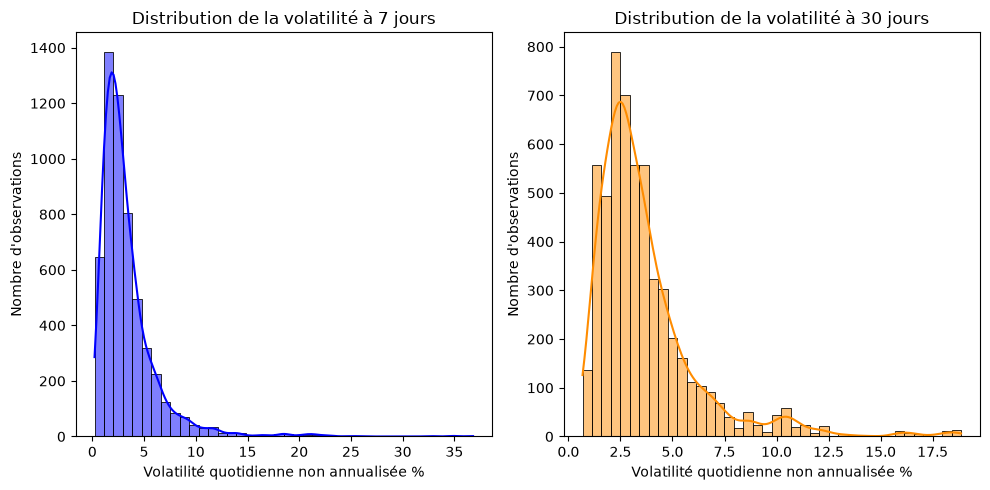

In [41]:
fig, axe = plt.subplots(
   nrows=1, 
   ncols=2,
   figsize=(10,5)
)


sns.histplot(
    target_7 * 100, 
    kde=True, 
    color="blue",
    ax=axe[0],
    bins=40,
)

axe[0].set_title("Distribution de la volatilité à 7 jours")
axe[0].set_xlabel("Volatilité quotidienne non annualisée %")
axe[0].set_ylabel("Nombre d'observations")

sns.histplot(
    target_30 * 100, 
    kde=True, 
    color="darkorange",
    ax=axe[1],
    bins=40,
)

axe[1].set_title("Distribution de la volatilité à 30 jours")
axe[1].set_xlabel("Volatilité quotidienne non annualisée %")
axe[1].set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

Les deux variables cibles présentent une distribution asymétrique à
droite. La volatilité future à 7 jours est davantage concentrée sur les
faibles valeurs, mais présente une queue plus longue et des valeurs
extrêmes plus élevées.

La volatilité à 30 jours est plus lissée : sa dispersion et son maximum
sont plus faibles. La prédiction à 7 jours pourrait donc être plus
sensible aux épisodes extrêmes, tandis que celle à 30 jours devrait
représenter des régimes de volatilité plus persistants.

## 2 - Analyser des corrélations entre les variables explicatives et les variables cibles

In [42]:
corr_7d = (
    dataset_7d
    .corr(
        numeric_only=True
    )
    ["target_volatility_7d"]
    .drop("target_volatility_7d")
    .sort_values(ascending=False)    
)

display(corr_7d)

volatility_30d        0.481901
volatility_14d        0.448097
volatility_7d         0.435782
volatility_3d         0.390791
daily_range           0.342166
unemployment_rate     0.184611
volume_change         0.108649
log_return_lag_7d     0.075829
log_return_lag_30d    0.062386
market_cap_change     0.047741
log_return_lag_1d     0.026331
log_return            0.014851
monetary_m3_rate     -0.054441
inflation_rate       -0.063501
rate_mro             -0.129416
Name: target_volatility_7d, dtype: float64

In [43]:
corr_7d_by_strength = corr_7d.reindex(
    corr_7d.abs().sort_values(ascending=False).index
)

display(
    corr_7d_by_strength.to_frame(
        name="corrélation avec la cible 7d"
    )
)

,corrélation avec la cible 7d
volatility_30d,0.481901
volatility_14d,0.448097
volatility_7d,0.435782
volatility_3d,0.390791
daily_range,0.342166
unemployment_rate,0.184611
rate_mro,-0.129416
volume_change,0.108649
log_return_lag_7d,0.075829
inflation_rate,-0.063501


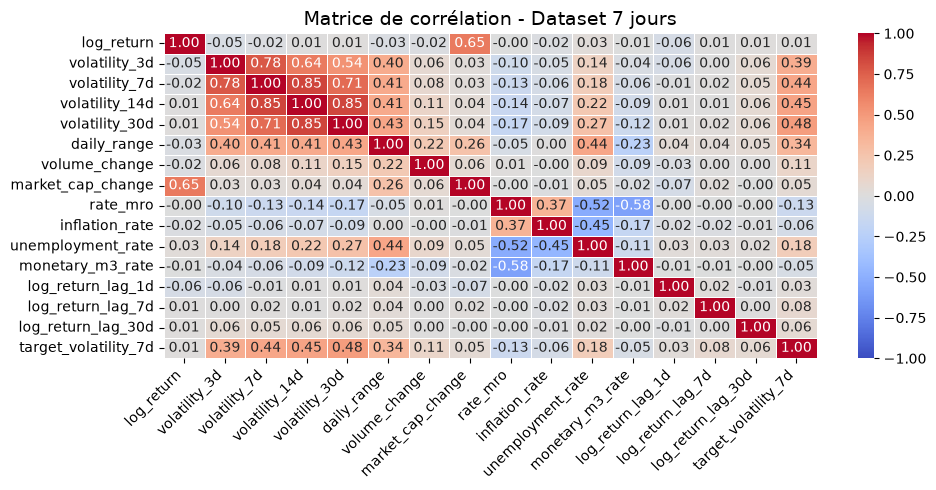

In [44]:
# Calculer la matrice de corrélation
correlation_matrix_7d = dataset_7d.corr(
    numeric_only=True
)

# Créer la figure
plt.figure(figsize=(10, 5))

# Afficher la matrice sous forme de carte de chaleur
sns.heatmap(
    correlation_matrix_7d,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title(
    "Matrice de corrélation - Dataset 7 jours",
    fontsize=14
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

La matrice de corrélation montre que les volatilités historiques sont
les variables les plus liées à la volatilité future à 7 jours. La
volatilité à 30 jours présente la corrélation la plus élevée avec la
cible (0,48), suivie des volatilités à 14, 7 et 3 jours.

Ces résultats confirment la persistance de la volatilité dans le temps.
Les différentes fenêtres de volatilité sont néanmoins fortement
corrélées entre elles, ce qui révèle une multicolinéarité à prendre en
compte, particulièrement pour les modèles linéaires.

Les variables macroéconomiques et les rendements retardés présentent
des corrélations linéaires plus faibles avec la cible. Elles ne sont
cependant pas nécessairement inutiles, car des modèles non linéaires
peuvent détecter des relations que la corrélation de Pearson ne révèle
pas. Enfin, ces corrélations décrivent des associations statistiques
et ne démontrent pas de relations causales.

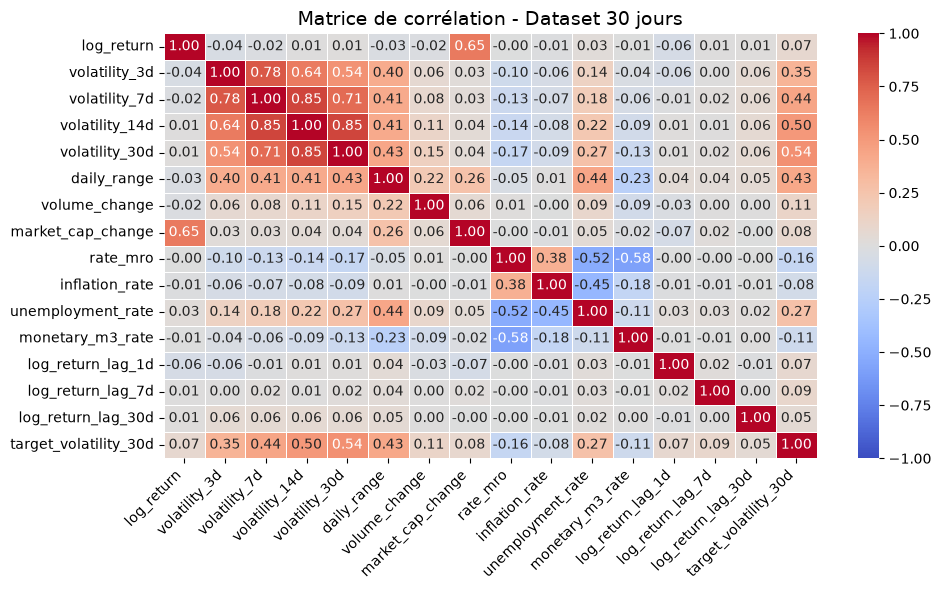

In [45]:
correlation_matrix_30d = dataset_30d.corr(
    numeric_only=True
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix_30d,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title(
    "Matrice de corrélation - Dataset 30 jours",
    fontsize=14
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

À l’horizon de 30 jours, les volatilités historiques restent les
variables les plus corrélées à la cible. La volatilité historique à
30 jours présente la relation la plus élevée (0,54), suivie de la
volatilité à 14 jours (0,50), de la volatilité à 7 jours (0,44) et de
l’amplitude journalière (0,43).

Comparativement à la cible à 7 jours, la cible à 30 jours semble
davantage associée aux indicateurs décrivant un régime de volatilité
persistant. La volatilité à 3 jours est en revanche légèrement plus
liée à l’horizon court.

Les indicateurs macroéconomiques présentent des corrélations linéaires
plus faibles. Ils sont néanmoins conservés pour permettre aux modèles
non linéaires d’identifier d’éventuelles relations complémentaires.
Ces associations statistiques ne permettent pas d’établir une
causalité.

## 3 - Comparer les distributions des ensembles train, validation et test 

### Selon l' horizons à 7 jours

In [46]:
# 1. Recréer les splits à 7 jours
from scripts.build_dataset.build_features_engineering import temporal_split_with_purge

train_7d, validation_7d, test_7d = temporal_split_with_purge(
    dataset_7d.reset_index(),
    horizon=7
)

In [47]:
# 2. Vérifier les périodes obtenues
splits_7d = {
    "Train": train_7d,
    "Validation": validation_7d,
    "Test": test_7d
}

for name, data in splits_7d.items():
    print(
        name,
        "| lignes :", len(data),
        "| début :", data["date"].min(),
        "| fin :", data["date"].max()
    )

Train | lignes : 4228 | début : 2010-08-14 00:00:00 | fin : 2022-12-24 00:00:00
Validation | lignes : 724 | début : 2023-01-01 00:00:00 | fin : 2024-12-24 00:00:00
Test | lignes : 613 | début : 2025-01-01 00:00:00 | fin : 2026-09-05 00:00:00


In [48]:
# 3. Préparer les données pour la comparaison
comparison_7d = pd.concat(
    [
        train_7d[
            ["target_volatility_7d"]
        ].assign(split="Train"),

        validation_7d[
            ["target_volatility_7d"]
        ].assign(split="Validation"),

        test_7d[
            ["target_volatility_7d"]
        ].assign(split="Test")
    ],
    ignore_index=True
)

comparison_7d["target_percent"] = (
    comparison_7d["target_volatility_7d"] * 100
)

In [49]:
# 4. Comparer les statistiques
summary_7d = (
    comparison_7d
    .groupby("split")["target_percent"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
)

display(summary_7d)

,count,mean,median,std,minimum,maximum
split,,,,,,
Test,613,2.028953,1.785714,1.094014,0.361786,8.168222
Train,4228,3.740844,2.914432,3.288654,0.300370,36.807509
Validation,724,2.291810,2.131698,1.049584,0.212495,6.853694


La distribution de la volatilité future à 7 jours évolue entre les ensembles temporels. La période d’entraînement présente une volatilité moyenne plus élevée, une dispersion plus importante et des événements extrêmes nettement plus marqués que les périodes de validation et de test. Ces différences indiquent un changement de régime de volatilité au cours du temps. Le modèle sera donc entraîné sur une période plus agitée que les périodes sur lesquelles il sera évalué. Cette situation devra être prise en compte lors de l’interprétation des performances.

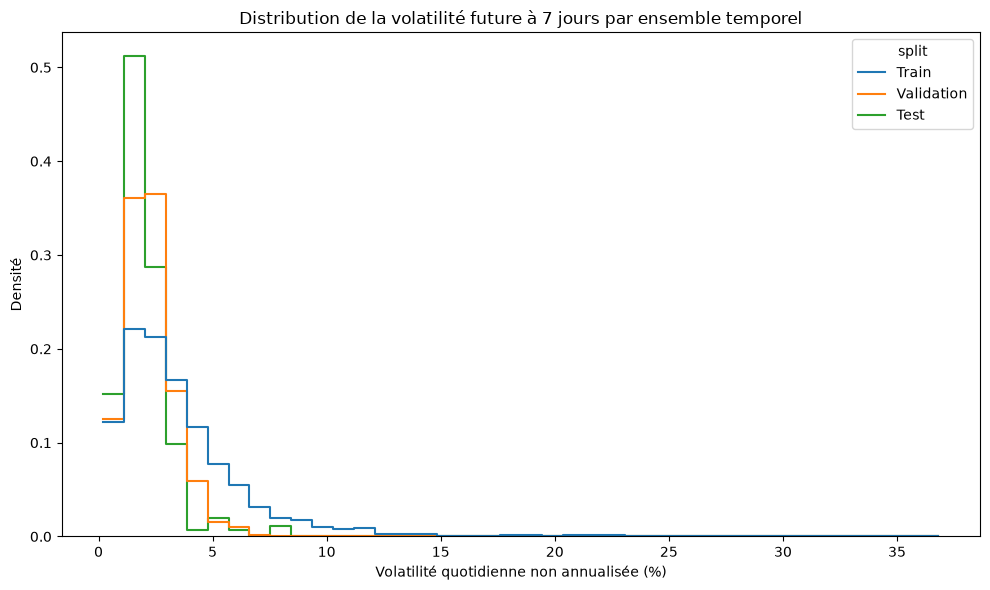

In [50]:
# 5. Comparer visuellement les distributions
plt.figure(figsize=(10, 6))

sns.histplot(
    data=comparison_7d,
    x="target_percent",
    hue="split",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)

plt.title(
    "Distribution de la volatilité future à 7 jours "
    "par ensemble temporel"
)
plt.xlabel("Volatilité quotidienne non annualisée (%)")
plt.ylabel("Densité")
plt.tight_layout()
plt.show()

La comparaison visuelle met en évidence une évolution de la distribution
de la cible à 7 jours. L’ensemble d’entraînement présente une dispersion
plus importante et contient davantage d’épisodes extrêmes, tandis que
les ensembles de validation et de test sont plus concentrés sur de
faibles niveaux de volatilité.

Cette différence suggère un changement de régime entre les périodes
historiques et les périodes les plus récentes. Elle devra être prise en
compte lors de l’interprétation des performances du modèle et dans le
dispositif futur de surveillance de la dérive des données.

### Selon l' horizons à 30 jours

In [51]:
# 1. Recréer les splits à 30 jours
train_30d, validation_30d, test_30d = temporal_split_with_purge(
    dataset_30d.reset_index(),
    horizon=30
)

In [52]:
# 2. Vérifier les périodes obtenues
splits_30d = {
    "Train": train_30d,
    "Validation": validation_30d,
    "Test": test_30d
}

for name, data in splits_30d.items():
    print(
        name,
        "| lignes :", len(data),
        "| début :", data["date"].min(),
        "| fin :", data["date"].max()
    )

Train | lignes : 4182 | début : 2010-08-14 00:00:00 | fin : 2022-12-01 00:00:00
Validation | lignes : 701 | début : 2023-01-01 00:00:00 | fin : 2024-12-01 00:00:00
Test | lignes : 590 | début : 2025-01-01 00:00:00 | fin : 2026-08-13 00:00:00


In [53]:
# 3. Préparer les données pour la comparaison
comparison_30d = pd.concat(
    [
        train_30d[
            ["target_volatility_30d"]
        ].assign(split="Train"),

        validation_30d[
            ["target_volatility_30d"]
        ].assign(split="Validation"),

        test_30d[
            ["target_volatility_30d"]
        ].assign(split="Test")
    ],
    ignore_index=True
)

comparison_30d["target_percent"] = (
    comparison_30d["target_volatility_30d"] * 100
)

display(comparison_30d.head(10))

,target_volatility_30d,split,target_percent
0,0.107934,Train,10.793382
1,0.100748,Train,10.074787
2,0.106682,Train,10.668215
3,0.070091,Train,7.009053
4,0.104685,Train,10.468462
5,0.104628,Train,10.462774
6,0.104275,Train,10.427498
7,0.103997,Train,10.399711
8,0.104015,Train,10.401515
9,0.104048,Train,10.404762


In [54]:
# 4. Comparer les statistiques
summary_30d = (
    comparison_30d
    .groupby("split")["target_percent"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
)

display(summary_30d)

,count,mean,median,std,minimum,maximum
split,,,,,,
Test,590,2.157289,2.014225,0.747680,1.101259,4.363824
Train,4182,4.137965,3.478178,2.738898,0.677954,18.865959
Validation,701,2.446189,2.376585,0.671890,0.841871,4.291424


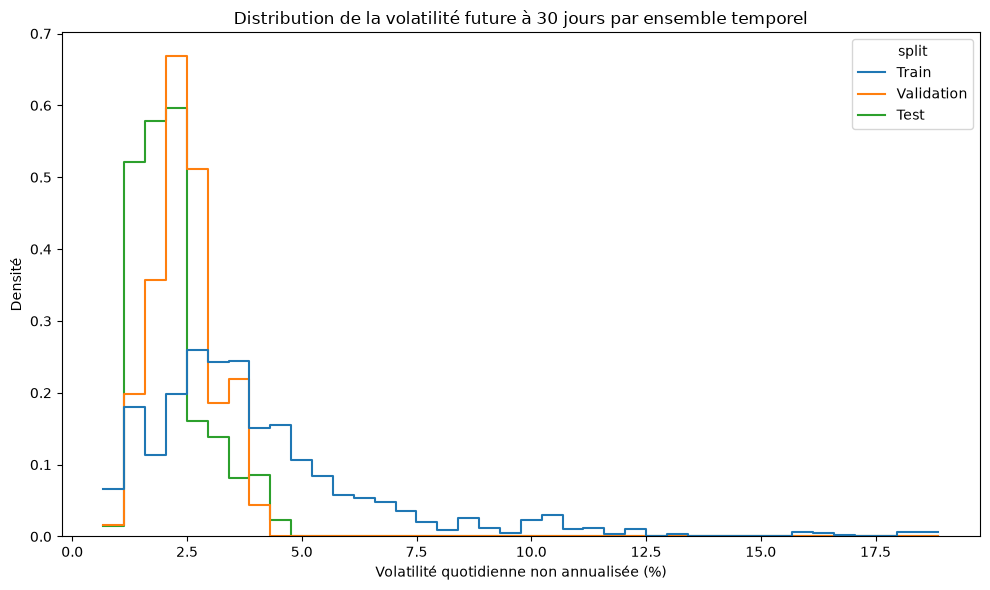

In [55]:
# 5. Comparer visuellement les distributions
plt.figure(figsize=(10, 6))

sns.histplot(
    data=comparison_30d,
    x="target_percent",
    hue="split",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)

plt.title(
    "Distribution de la volatilité future à 30 jours "
    "par ensemble temporel"
)
plt.xlabel("Volatilité quotidienne non annualisée (%)")
plt.ylabel("Densité")
plt.tight_layout()
plt.show()

L’analyse de la cible à 30 jours met en évidence une différence importante entre les ensembles temporels. La période d’entraînement présente une volatilité moyenne plus élevée, une dispersion plus forte et des valeurs extrêmes nettement supérieures à celles des périodes de validation et de test. Ces résultats confirment l’existence d’un changement de régime de volatilité au cours du temps. La cible à 30 jours reste toutefois moins sensible aux chocs ponctuels que la cible à 7 jours, en raison de son horizon de calcul plus long. Cette différence de distribution devra être prise en compte lors de l’évaluation et de l’interprétation des performances du modèle.

## 4 - Tester la stationnarité des rendements logarithmiques

L’objectif est de vérifier si les propriétés statistiques de log_return restent globalement stables dans le temps. 
Tu peux utiliser le test ADF - Augmented Dickey-Fuller.

In [56]:
from statsmodels.tsa.stattools import adfuller

# Récupérer les rendements sans valeurs manquantes
log_returns = dataset_7d["log_return"].dropna()

# Réaliser le test ADF
adf_result = adfuller(log_returns)

print("Statistique ADF :", adf_result[0])
print("p-value :", adf_result[1])
print("Nombre de retards utilisés :", adf_result[2])
print("Nombre d'observations :", adf_result[3])

print("\nValeurs critiques :")
for level, value in adf_result[4].items():
    print(f"{level} : {value}")

Statistique ADF : -11.153864350648677
p-value : 2.898438944350957e-20
Nombre de retards utilisés : 27
Nombre d'observations : 5551

Valeurs critiques :
1% : -3.4315285852166277
5% : -2.8620608185993297
10% : -2.5670472304152314


C:\Users\PATRICIA\AppData\Local\Temp\ipykernel_10688\869241177.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(log_returns)


In [57]:
# La règle de décision pour le test de racine unitaire ADF 

if adf_result[1] < 0.05:
    print("Rejet de H₀ : les rendements logarithmiques sont stationnaires.")
else:
    print("H₀ n'est pas rejetée : la stationnarité n'est pas démontrée.")

Rejet de H₀ : les rendements logarithmiques sont stationnaires.


## 5 - Conclusions de l’analyse exploratoire et conséquences pour la modélisation

| Observation issue de l’EDA | Interprétation | Conséquence pour la modélisation |
|---|---|---|
| Les deux variables cibles sont asymétriques vers la droite et comportent des valeurs extrêmes. | La majorité des périodes présente une volatilité faible ou modérée, tandis que quelques périodes de crise produisent des valeurs très élevées. | Utiliser conjointement la MAE, qui mesure l’erreur moyenne courante, et la RMSE, qui pénalise davantage les erreurs importantes commises pendant les périodes de forte volatilité. |
| La cible à 7 jours présente des pics plus extrêmes que la cible à 30 jours. | La volatilité à 7 jours réagit fortement aux chocs récents, tandis que la fenêtre de 30 jours lisse davantage les variations ponctuelles. | Entraîner et évaluer séparément un modèle pour l’horizon 7 jours et un autre pour l’horizon 30 jours. Les performances des deux modèles ne devront pas être interprétées de manière identique. |
| Les distributions des cibles diffèrent entre les ensembles d’entraînement, de validation et de test. | La période d’entraînement est plus volatile et plus dispersée que les périodes de validation et de test, ce qui met en évidence une évolution des régimes de volatilité dans le temps. | Conserver un découpage chronologique, sans mélange aléatoire des observations, et évaluer la capacité des modèles à généraliser sur des périodes présentant un régime différent de celui de l’entraînement. |
| Les cibles utilisent des rendements futurs sur 7 ou 30 jours. | Deux observations proches d’une frontière temporelle pourraient partager une partie des données utilisées pour calculer leur cible et provoquer une fuite d’information. | Conserver le découpage temporel avec purge ou embargo correspondant à l’horizon de prédiction. |
| Les volatilités historiques à 3, 7, 14 et 30 jours présentent les corrélations les plus importantes avec les cibles. | La volatilité passée apporte une information utile pour prévoir la volatilité future, ce qui confirme le phénomène de persistance de la volatilité. | Conserver ces variables parmi les principales variables explicatives et vérifier leur importance après l’entraînement des modèles. |
| `daily_range` présente également une corrélation positive avec les deux cibles. | Une forte amplitude entre le prix le plus haut et le prix le plus bas d’une journée peut signaler une agitation du marché susceptible de se prolonger. | Conserver `daily_range` comme variable explicative potentiellement utile. |
| Les variables `volatility_7d`, `volatility_14d` et `volatility_30d` sont fortement corrélées entre elles. | Elles mesurent le même phénomène sur des fenêtres différentes et contiennent donc une information partiellement redondante. | Vérifier la multicolinéarité pour les modèles linéaires, notamment avec le VIF. Selon les résultats, utiliser une régularisation Ridge/Lasso ou sélectionner certaines variables. |
| Certaines variables, notamment les rendements retardés et plusieurs variables macroéconomiques, présentent une faible corrélation linéaire avec les cibles. | Une faible corrélation de Pearson signifie qu’aucune relation linéaire forte n’a été détectée, mais elle n’exclut pas une relation non linéaire, retardée ou conditionnelle. | Ne pas supprimer automatiquement ces variables sur la seule base de la corrélation. Vérifier leur utilité à l’aide des résultats du benchmark et de l’importance des variables. |
| Les relations entre les variables explicatives et les cibles peuvent être complexes. | La corrélation de Pearson ne mesure que les relations linéaires et peut ignorer les interactions entre plusieurs variables ou les effets propres aux périodes de crise. | Comparer un modèle linéaire de référence à des modèles capables de représenter des relations non linéaires, comme Random Forest, XGBoost ou LightGBM. |
| Le test ADF rejette fortement l’hypothèse de non-stationnarité des rendements logarithmiques. | La transformation des prix en rendements logarithmiques a permis d’obtenir une série statistiquement stationnaire selon le test ADF. | Utiliser directement `log_return` comme variable explicative, sans appliquer une différenciation supplémentaire uniquement dans le but de rendre la série stationnaire. |
| Les rendements sont stationnaires, mais les périodes calmes et agitées persistent. | La stationnarité des rendements ne signifie pas que leur variance est constante : le marché peut toujours présenter des regroupements de volatilité et des changements de régime. | Conserver les variables de volatilité glissante et interpréter les performances des modèles selon les différents régimes de marché. |